In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import openml
import yaml
import tqdm
from pymoo.indicators.hv import HV
import warnings
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

from utility import compute_min_max, get_pareto_front, compute_ranks, compute_extremes, get_all_dataframes, get_group_task_ids
from colors import COLORS

In [8]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

FONT_SIZE = 12

keys = ["random", "so-smac", "mo-smac", "so-asha", "mo-asha", "nsga2"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.weight": "normal",
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,      # axis labels
    "axes.titlesize": FONT_SIZE,      # subplot titles
    "xtick.labelsize": FONT_SIZE,     # x tick labels
    "ytick.labelsize": FONT_SIZE,     # y tick labels
    "legend.fontsize": FONT_SIZE,     # legend
    "figure.titlesize": FONT_SIZE + 4     # suptitle
})

In [9]:
data = pd.read_csv("./data/raaml_results_gbmlp.csv")
print(list(data.columns))

['task_id', 'method', 'seed', 'config_id', 'model', 'time_5fcv', 'bmp_RMSE', 'bmp_inference_time', 'bmp_energy_consumption', 'status', 'ensembling_RMSE', 'ensembling_inference_time_freq_1500000_cores_1', 'ensembling_energy_consumption_freq_1500000_cores_1', 'ensembling_inference_time_freq_1500000_cores_2', 'ensembling_energy_consumption_freq_1500000_cores_2', 'ensembling_inference_time_freq_1500000_cores_3', 'ensembling_energy_consumption_freq_1500000_cores_3', 'ensembling_inference_time_freq_1500000_cores_4', 'ensembling_energy_consumption_freq_1500000_cores_4', 'ensembling_inference_time_freq_1500000_cores_5', 'ensembling_energy_consumption_freq_1500000_cores_5', 'ensembling_inference_time_freq_1500000_cores_6', 'ensembling_energy_consumption_freq_1500000_cores_6', 'ensembling_inference_time_freq_1500000_cores_7', 'ensembling_energy_consumption_freq_1500000_cores_7', 'ensembling_inference_time_freq_1500000_cores_8', 'ensembling_energy_consumption_freq_1500000_cores_8', 'ensembling_in

In [10]:
data_random = data[(data["method"] == "random") & (~np.isnan(data["ensembling_inference_time_freq_1500000_cores_1"]))]

In [11]:
COLOR_LIST = list(COLORS.values())

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_tradeoff(
    inf_times,
    energies,
    frequencies={1.5: "1.5 GHz", 2.1: "2.1 GHz", 2.8: "2.8 GHz", 3.7: "Boost (3.7GHz)"},
    title=None,
    showfliers=True,
    save_suffix="amd",
):
    fig, ax = plt.subplots(figsize=(8, 7))

    # ----------------------------------------------------------
    # DATA PREP
    # ----------------------------------------------------------
    freqs = list(frequencies.keys())             # real numeric frequencies
    labels = list(frequencies.values())          # labels
    n = len(freqs)

    # For first plot (to avoid compression)
    x_positions = np.arange(n)                   # 0,1,2,3...
    width = 0.20                                 # box offset

    # For second plot tick spacing
    if n > 8:
        freqs_selected = freqs[::2]
        frequency_ticks = labels[::2]
    else:
        freqs_selected = freqs
        frequency_ticks = labels

    for i, x in enumerate(x_positions):
        # inference box
        ax.boxplot(
            inf_times[i],
            positions=[x - width],
            widths=0.15,
            patch_artist=True,
            showfliers=showfliers,
            boxprops=dict(facecolor=COLOR_LIST[0]),
            medianprops=dict(color="black")
        )
        # energy box
        ax.boxplot(
            energies[i],
            positions=[x + width],
            widths=0.15,
            patch_artist=True,
            showfliers=showfliers,
            boxprops=dict(facecolor=COLOR_LIST[1]),
            medianprops=dict(color="black")
        )

    ax.plot([], [], color=COLOR_LIST[0], label="Inference Time")
    ax.plot([], [], color=COLOR_LIST[1], label="Energy Consumption")
    ax.legend()

    # axis labels
    ax.set_xlabel("CPU Frequency")
    ax.set_ylabel("Normalised Metric Value")

    # integer → label mapping
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=0 if n <= 4 else 45)

    # bounds and grid
    ax.set_xlim(-0.7, n - 0.3)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    plt.savefig(f"./figures/4/boxplot_tradeoff_{save_suffix}.pdf")

    # ----------------------------------------------------------
    # RIGHT SUBPLOT — REAL FREQUENCY PLOT
    # ----------------------------------------------------------
    
    fig, ax1 = plt.subplots(figsize=(8, 7))
    
    mean_inf_time = [np.mean(inf_times[i]) for i in range(n)]
    std_inf_time  = [np.std(inf_times[i])  for i in range(n)]
    mean_energy   = [np.mean(energies[i])  for i in range(n)]
    std_energy    = [np.std(energies[i])   for i in range(n)]

    # inference line
    ax1.plot(freqs, mean_inf_time, marker='o', color=COLOR_LIST[0], label="Inference Time")
    ax1.fill_between(
        freqs,
        np.array(mean_inf_time) - np.array(std_inf_time),
        np.array(mean_inf_time) + np.array(std_inf_time),
        alpha=0.2, color=COLOR_LIST[0]
    )

    # energy line
    ax1.plot(freqs, mean_energy, marker='o', color=COLOR_LIST[1], label="Energy Consumption")
    ax1.fill_between(
        freqs,
        np.array(mean_energy) - np.array(std_energy),
        np.array(mean_energy) + np.array(std_energy),
        alpha=0.2, color=COLOR_LIST[1]
    )

    # tick selection
    ax1.set_xticks(freqs_selected)
    ax1.set_xticklabels(frequency_ticks)

    ax1.set_xlabel("CPU Frequency")
    ax1.set_ylabel("Max-Normalised Metric Value")
    ax1.legend(title="Metric", loc="upper center")

    ax1.set_xlim(min(freqs) - 0.1, max(freqs) + 0.1)

    plt.savefig(f"./figures/4/fs_tradeoff_{save_suffix}.pdf", bbox_inches='tight')


# Frequency Scaling Tradeoffs (AMD)

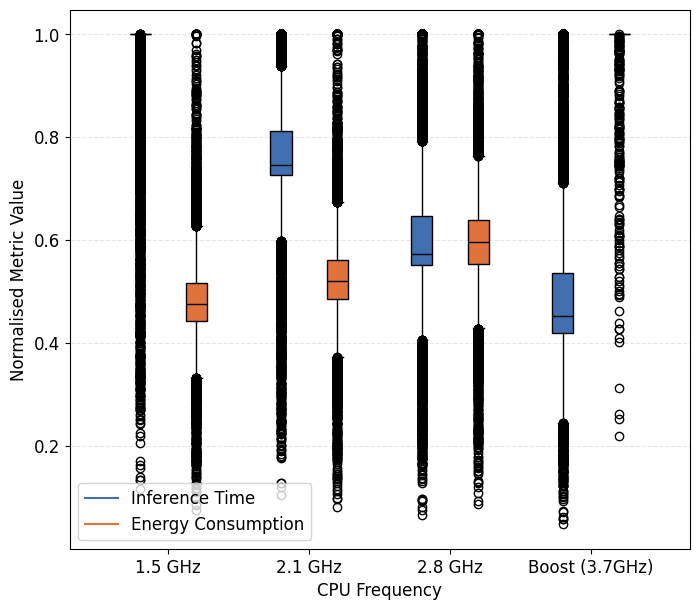

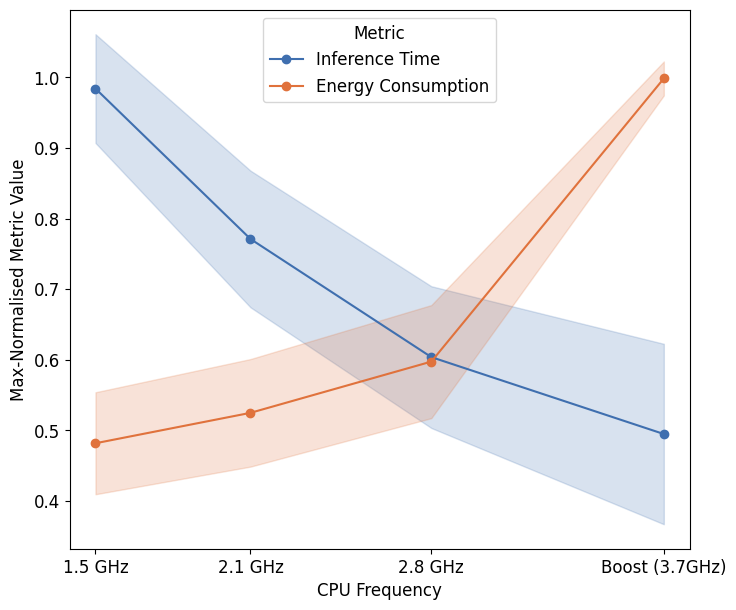

In [7]:
#fig, ax = plt.subplots(figsize=(6, 4))
inf_times_15 = data_random["ensembling_inference_time_freq_1500000_cores_1"]
inf_times_21 = data_random["ensembling_inference_time_freq_2100000_cores_1"]
inf_times_28 = data_random["ensembling_inference_time_freq_2800000_cores_1"]
inf_times_boost = data_random["ensembling_inference_time_freq_boost_cores_1"]

inf_times = np.array([inf_times_15, inf_times_21, inf_times_28, inf_times_boost])
#inf_times_norm = (inf_times - inf_times.min(axis=0, keepdims=True)) / (inf_times.max(axis=0, keepdims=True) - inf_times.min(axis=0, keepdims=True) + 1e-12)
inf_times_norm = inf_times / inf_times.max(axis=0, keepdims=True)

energies_15 = data_random["ensembling_energy_consumption_freq_1500000_cores_1"]
energies_21 = data_random["ensembling_energy_consumption_freq_2100000_cores_1"]
energies_28 = data_random["ensembling_energy_consumption_freq_2800000_cores_1"]
energies_boost = data_random["ensembling_energy_consumption_freq_boost_cores_1"]
energies = np.array([energies_15, energies_21, energies_28, energies_boost])
#energies_norm = (energies - energies.min(axis=0, keepdims=True)) / (energies.max(axis=0, keepdims=True) - energies.min(axis=0, keepdims=True) + 1e-12)
energies_norm = energies / energies.max(axis=0, keepdims=True)

plot_tradeoff(
    inf_times_norm,
    energies_norm,
    title="Tradeoff between Inference Time and Energy Consumption",
    showfliers=True,
    save_suffix="amd"
)

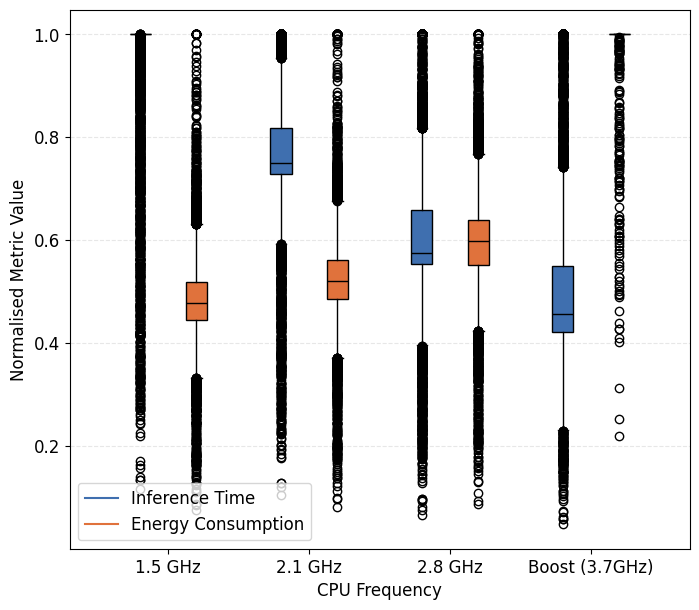

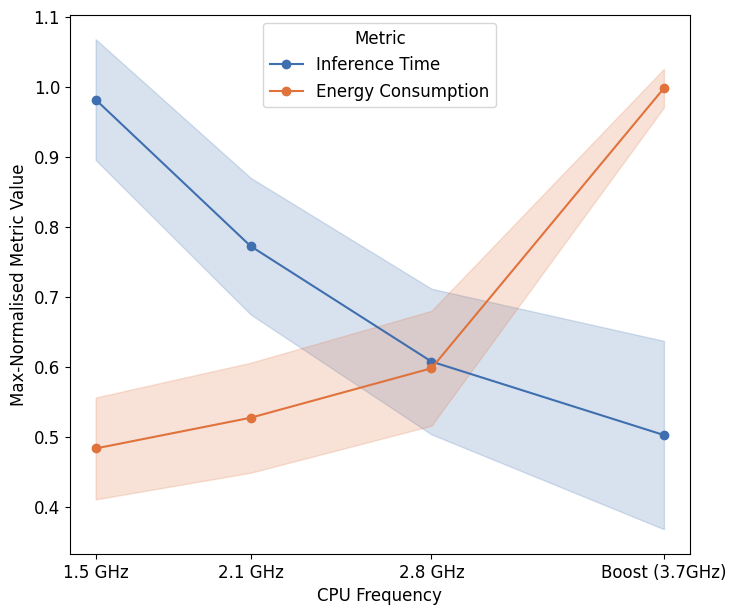

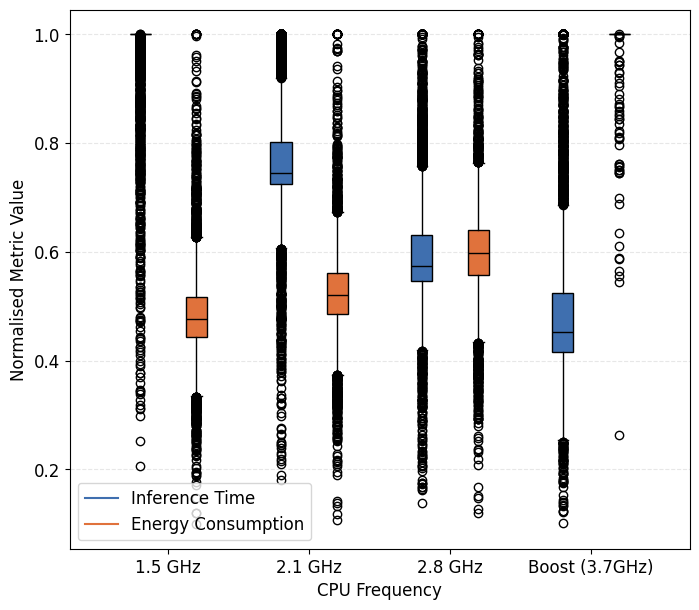

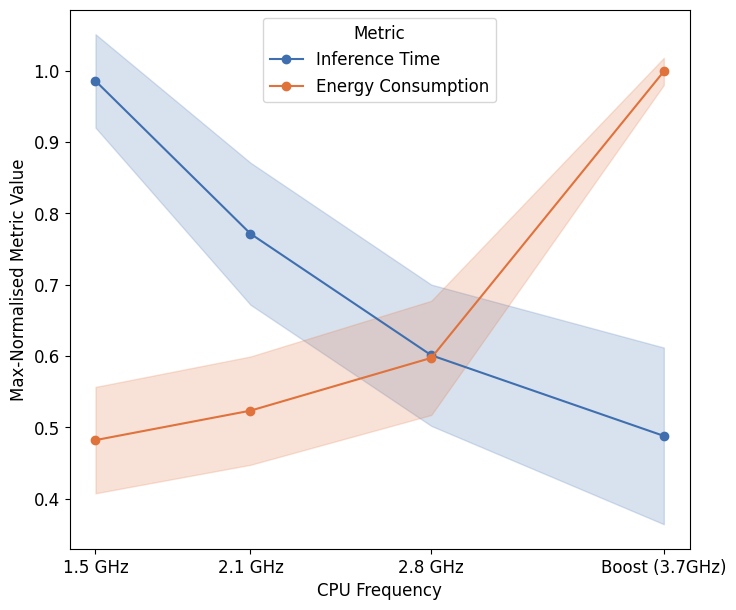

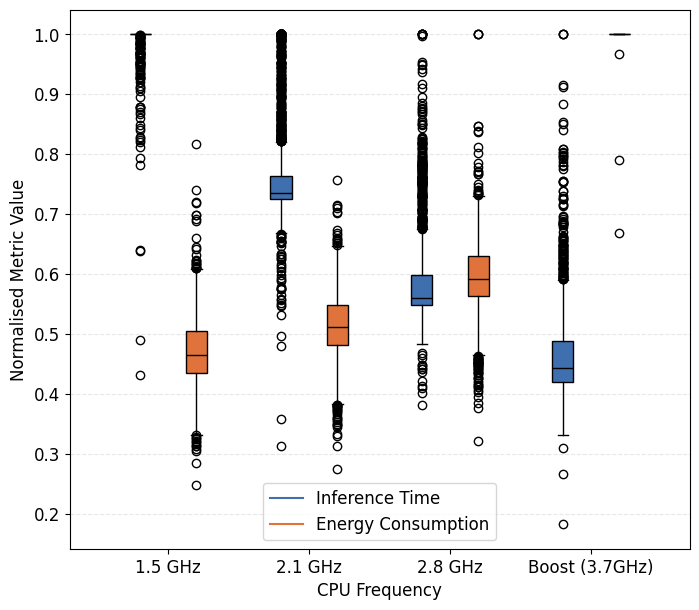

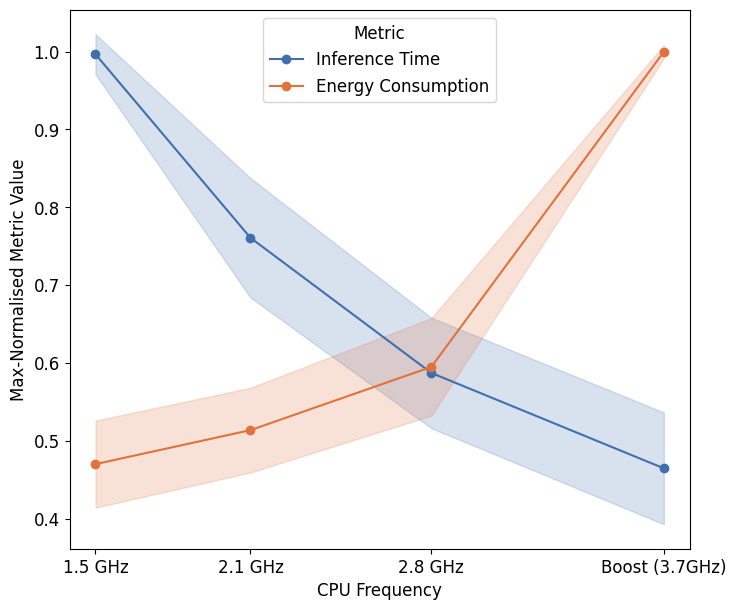

In [8]:
for group_key, group_name in {"Fast Datasets": "fast", "Medium Datasets": "medium", "Slow Datasets": "slow"}.items():
    task_ids = get_group_task_ids(group_name)
    data_group = data_random[data_random["task_id"].isin(task_ids)]
    
    inf_times_15 = data_group["ensembling_inference_time_freq_1500000_cores_1"]
    inf_times_21 = data_group["ensembling_inference_time_freq_2100000_cores_1"]
    inf_times_28 = data_group["ensembling_inference_time_freq_2800000_cores_1"]
    inf_times_boost = data_group["ensembling_inference_time_freq_boost_cores_1"]
    inf_times = np.array([inf_times_15, inf_times_21, inf_times_28, inf_times_boost])
    #inf_times_norm = (inf_times - inf_times.min(axis=0, keepdims=True)) / (inf_times.max(axis=0, keepdims=True) - inf_times.min(axis=0, keepdims=True) + 1e-12)
    inf_times_norm = inf_times / inf_times.max(axis=0, keepdims=True)

    energies_15 = data_group["ensembling_energy_consumption_freq_1500000_cores_1"]
    energies_21 = data_group["ensembling_energy_consumption_freq_2100000_cores_1"]
    energies_28 = data_group["ensembling_energy_consumption_freq_2800000_cores_1"]
    energies_boost = data_group["ensembling_energy_consumption_freq_boost_cores_1"]
    energies = np.array([energies_15, energies_21, energies_28, energies_boost])
    energies_norm = energies / energies.max(axis=0, keepdims=True)
    #energies_norm = (energies - energies.min(axis=0, keepdims=True)) / (energies.max(axis=0, keepdims=True) - energies.min(axis=0, keepdims=True) + 1e-12)
    plot_tradeoff(inf_times_norm, energies_norm, title=f"Tradeoff on {group_key}", save_suffix=f"amd_{group_name}", showfliers=True)

In [9]:
def plot_tradeoff_by_time(
    inf_times_absolute,
    energies_absolute,
    frequencies={1.5: "1.5 GHz", 2.1: "2.1 GHz", 2.8: "2.8 GHz", 3.7: "Boost (3.7GHz)"},
    title=None,
    n_bins=10,
    save_suffix="amd"
):
    # Create a matrix plot that shows the max-normalized energy consumption for different bins of inference times and different frequencies.
    bin_edges = np.logspace(np.log10(inf_times_absolute[-1].min()), np.log10(inf_times_absolute[-1].max()), num=n_bins)
    upper_bin_edges = bin_edges[1:]
    lower_bin_edges = bin_edges[:-1]

    energies_norm = energies_absolute / energies_absolute.max(axis=0, keepdims=True)

    matrix = np.zeros((len(lower_bin_edges), len(frequencies)))

    for j, upper in enumerate(upper_bin_edges):
        lower = lower_bin_edges[j]
        for i, freq in enumerate(frequencies.keys()):
            inf_times_freq = inf_times_absolute[-1]
            energies_freq = energies_norm[i]

            mask = (inf_times_freq >= lower) & (inf_times_freq < upper)
            if np.any(mask):
                energies_in_bin = energies_freq[mask]
                matrix[j, i] = np.mean(energies_in_bin)
            else:
                matrix[j, i] = np.nan

    fig, ax = plt.subplots(figsize=(10, 7))
    
    vmin, vmax = matrix[np.isfinite(matrix)].min(), matrix[np.isfinite(matrix)].max()
    cax = ax.imshow(matrix, aspect='auto', origin='lower', cmap='viridis', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    fig.colorbar(cax, label='Max-Normalised Energy Consumption')
    ax.set_yticks(np.arange(len(lower_bin_edges)))
    ax.set_yticklabels([f"{lower_bin_edges[i]:.3f}-{upper_bin_edges[i]:.3f}" for i in range(len(lower_bin_edges))])
    ax.set_xticks(np.arange(len(frequencies)))
    ax.set_xticklabels(list(frequencies.values()), rotation=45)
    ax.set_xlabel("CPU Frequency")
    ax.set_ylabel("Inference Time at max. Frequency (s)")
    plt.tight_layout()
    plt.savefig(f"./figures/4/heatmap_tradeoff_{save_suffix}.pdf")

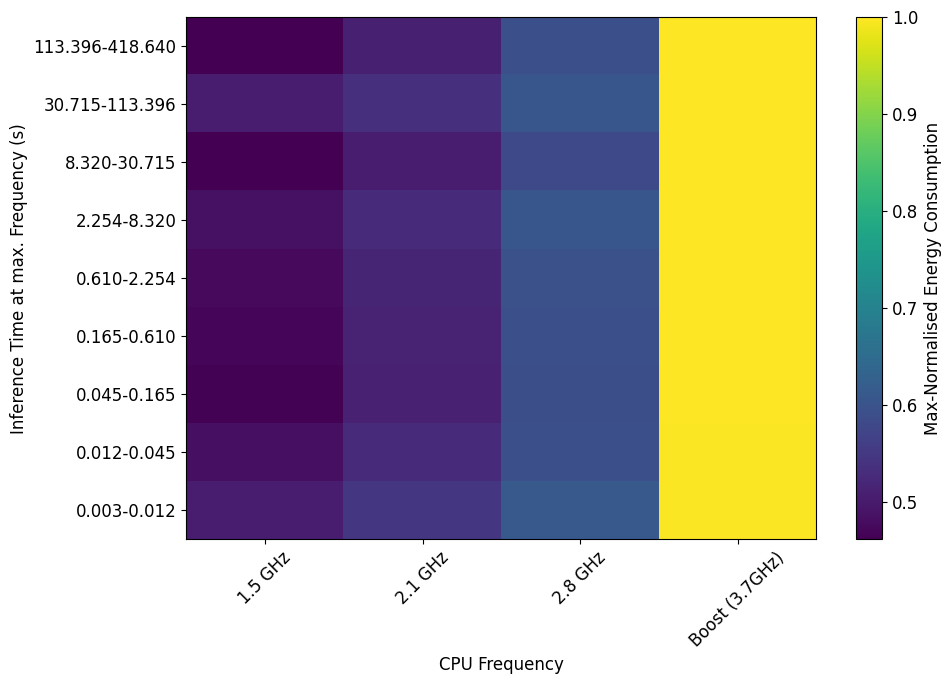

In [10]:
inf_times_15 = data_random["ensembling_inference_time_freq_1500000_cores_1"]
inf_times_21 = data_random["ensembling_inference_time_freq_2100000_cores_1"]
inf_times_28 = data_random["ensembling_inference_time_freq_2800000_cores_1"]
inf_times_boost = data_random["ensembling_inference_time_freq_boost_cores_1"]

inf_times = np.array([inf_times_15, inf_times_21, inf_times_28, inf_times_boost])

energies_15 = data_random["ensembling_energy_consumption_freq_1500000_cores_1"]
energies_21 = data_random["ensembling_energy_consumption_freq_2100000_cores_1"]
energies_28 = data_random["ensembling_energy_consumption_freq_2800000_cores_1"]
energies_boost = data_random["ensembling_energy_consumption_freq_boost_cores_1"]
energies = np.array([energies_15, energies_21, energies_28, energies_boost])

plot_tradeoff_by_time(
    inf_times,
    energies,
    title="Tradeoff between Inference Time and Energy Consumption",
    save_suffix="amd"
)

# Frequency Scaling Tradeoffs (Intel)

In [11]:
data_intel = []
for csv_file in os.listdir("./data/fs_intel/"):
    if csv_file.endswith(".csv"):
        task_id = int(csv_file.split(".")[0])
        df = pd.read_csv(os.path.join("./data/fs_intel/", csv_file))
        df["task_id"] = task_id
        data_intel.append(df)
data_intel = pd.concat(data_intel, ignore_index=True)

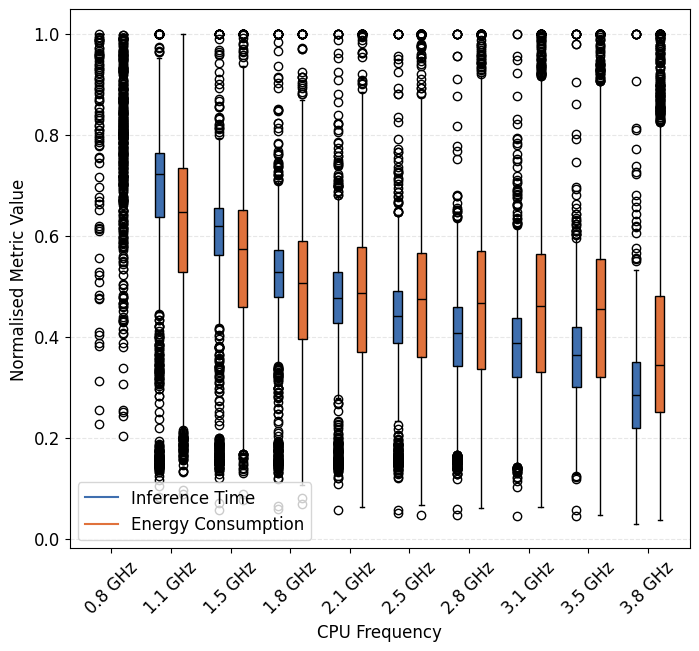

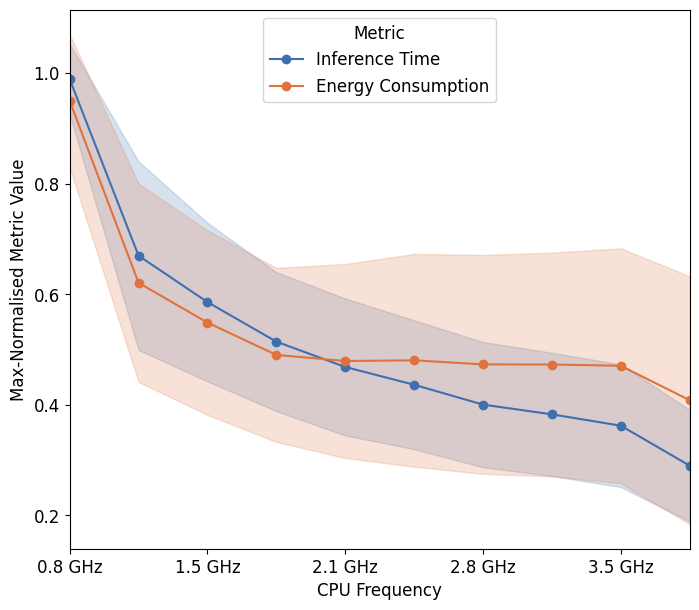

In [12]:
frequencies = data_intel["frequency"].unique().tolist()
frequencies.sort()
inf_times_intel = []
energies_intel = []

for freq in frequencies:
    df_freq = data_intel[data_intel["frequency"] == freq]
    inf_times_intel.append(df_freq["inference_time"].values)
    energies_intel.append(df_freq["energy_consumption"].values)

inf_times_intel = np.array(inf_times_intel)
energies_intel = np.array(energies_intel)

inf_times_intel_norm = inf_times_intel / inf_times_intel.max(axis=0, keepdims=True)
energies_intel_norm = energies_intel / energies_intel.max(axis=0, keepdims=True)

plot_tradeoff(
    inf_times_intel_norm,
    energies_intel_norm,
    frequencies={freq: f"{freq/1e6:.1f} GHz" for freq in frequencies},
    title="Tradeoff between Inference Time and Energy Consumption on Intel CPU",
    showfliers=True,
    save_suffix="intel"
)

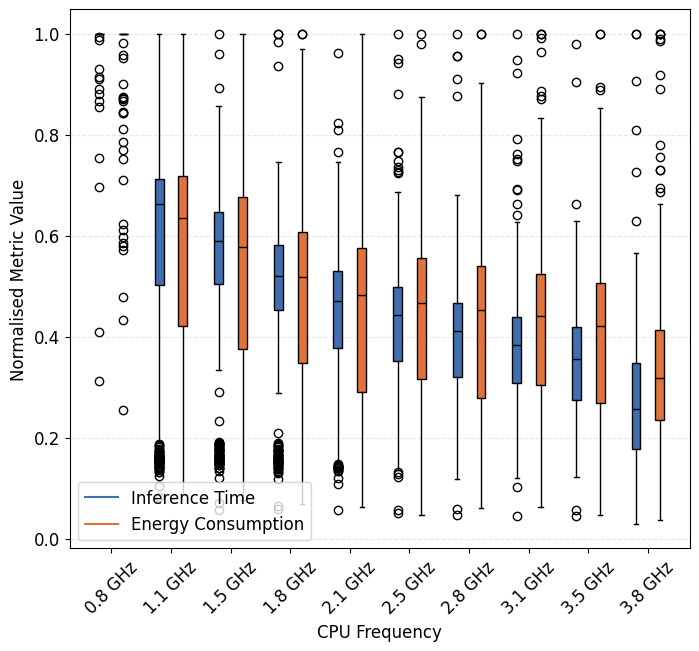

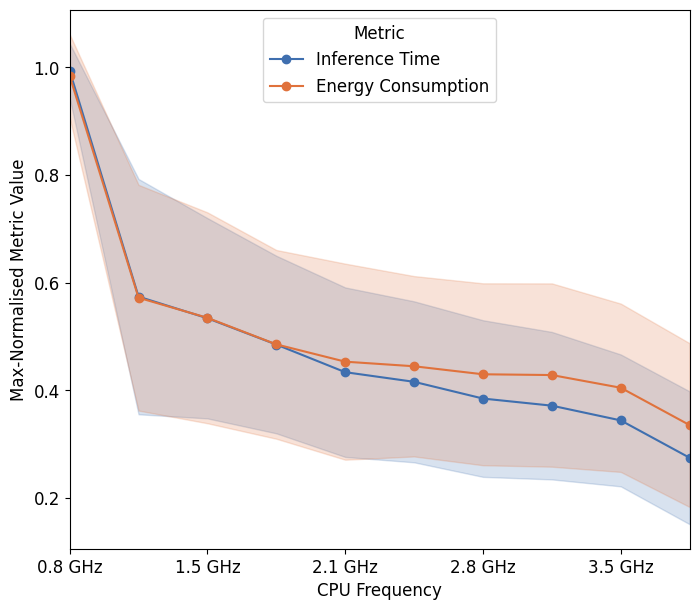

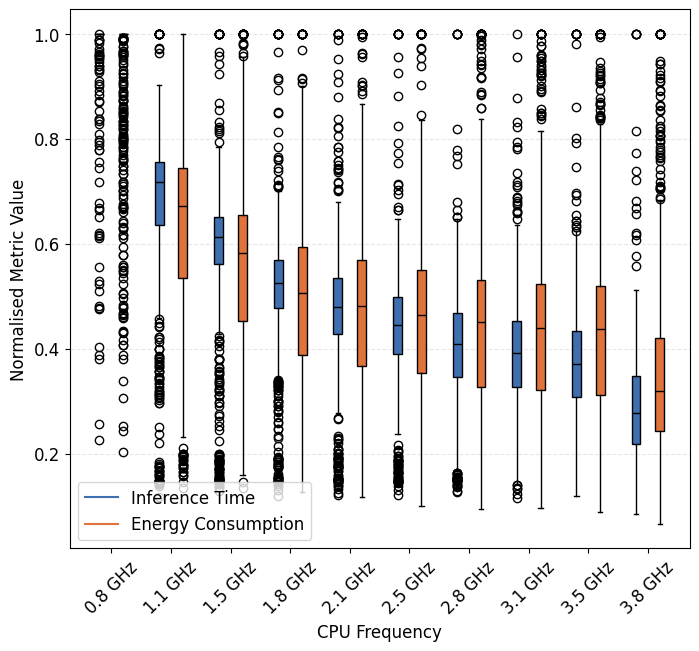

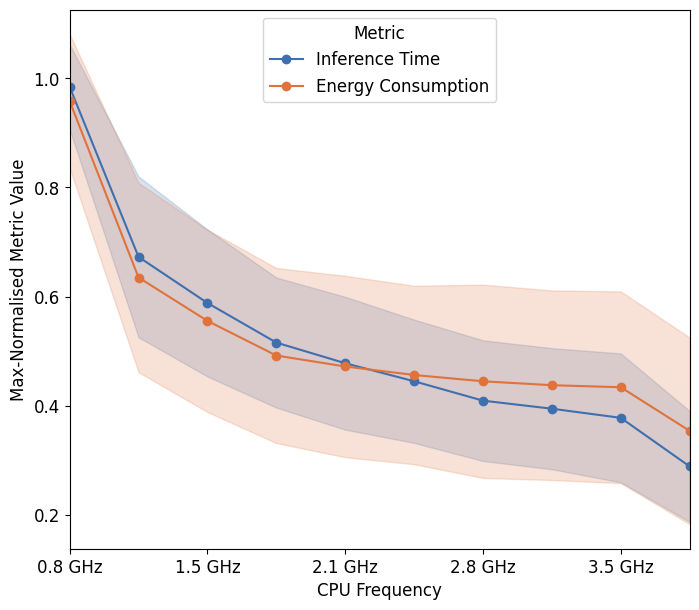

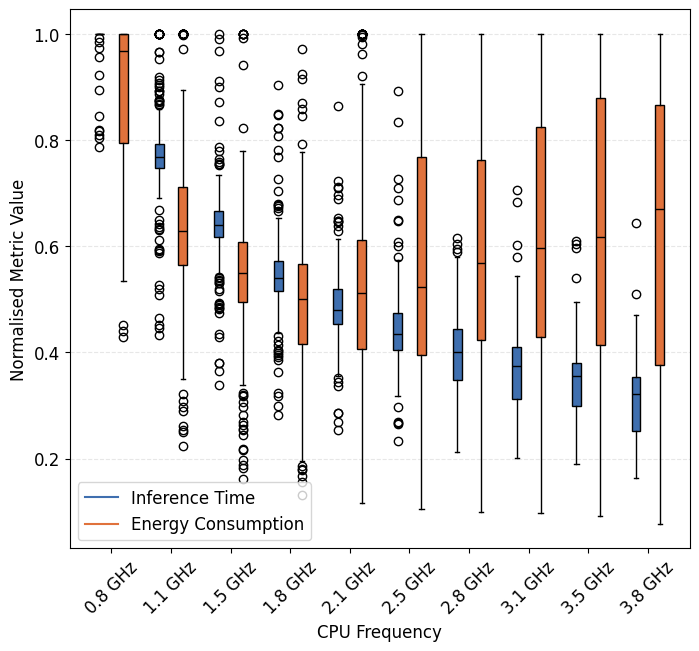

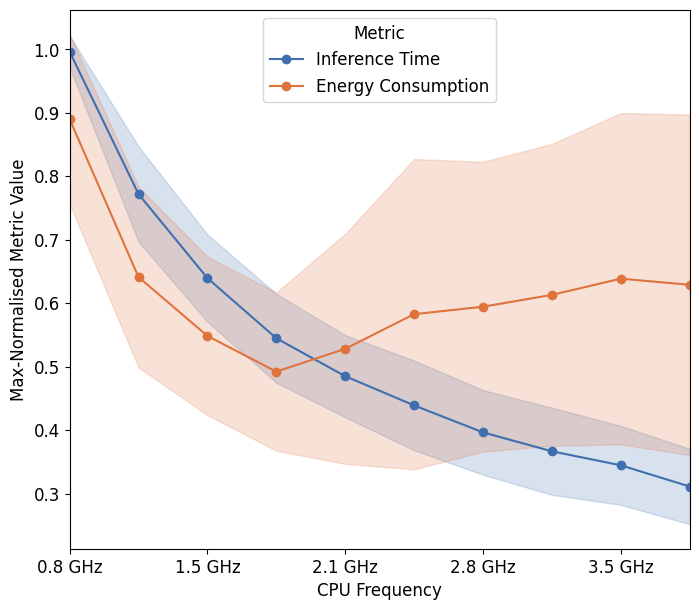

In [13]:
for group_key, group_name in {"Fast Datasets": "fast", "Medium Datasets": "medium", "Slow Datasets": "slow"}.items():
    task_ids = get_group_task_ids(group_name)
    data_group = data_intel[data_intel["task_id"].isin(task_ids)]
    inf_times_intel = []
    energies_intel = []

    for freq in frequencies:
        df_freq = data_group[data_group["frequency"] == freq]
        inf_times_intel.append(df_freq["inference_time"].values)
        energies_intel.append(df_freq["energy_consumption"].values)
    inf_times_intel = np.array(inf_times_intel)
    energies_intel = np.array(energies_intel)
    inf_times_intel_norm = inf_times_intel / inf_times_intel.max(axis=0, keepdims=True)
    energies_intel_norm = energies_intel / energies_intel.max(axis=0, keepdims=True)
    plot_tradeoff(
        inf_times_intel_norm,
        energies_intel_norm,
        frequencies={freq: f"{freq/1e6:.1f} GHz" for freq in frequencies},
        title=f"Tradeoff on Intel CPU on {group_key}",
        save_suffix=f"intel_{group_name}",
        showfliers=True
    )

0.0042631393298506 35.400498610921204


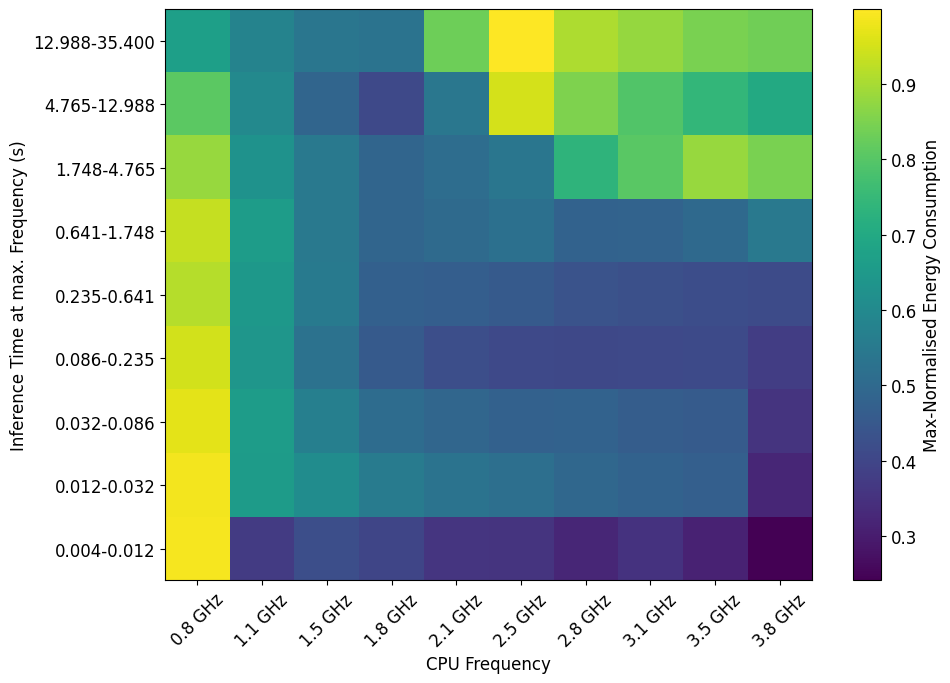

In [14]:
frequencies = data_intel["frequency"].unique().tolist()
frequencies.sort()
inf_times_intel = []
energies_intel = []

for freq in frequencies:
    df_freq = data_intel[data_intel["frequency"] == freq]
    inf_times_intel.append(df_freq["inference_time"].values)
    energies_intel.append(df_freq["energy_consumption"].values)

inf_times_intel = np.array(inf_times_intel)
energies_intel = np.array(energies_intel)

print(inf_times_intel[-1].min(), inf_times_intel[-1].max())

plot_tradeoff_by_time(
    inf_times_intel,
    energies_intel,
    frequencies={freq: f"{freq/1e6:.1f} GHz" for freq in frequencies},
    title="Tradeoff between Inference Time and Energy Consumption on Intel CPU",
    save_suffix="intel"
)

# Parallelization Tradeoffs

In [12]:
print(list(data_random.columns))

['task_id', 'method', 'seed', 'config_id', 'model', 'time_5fcv', 'bmp_RMSE', 'bmp_inference_time', 'bmp_energy_consumption', 'status', 'ensembling_RMSE', 'ensembling_inference_time_freq_1500000_cores_1', 'ensembling_energy_consumption_freq_1500000_cores_1', 'ensembling_inference_time_freq_1500000_cores_2', 'ensembling_energy_consumption_freq_1500000_cores_2', 'ensembling_inference_time_freq_1500000_cores_3', 'ensembling_energy_consumption_freq_1500000_cores_3', 'ensembling_inference_time_freq_1500000_cores_4', 'ensembling_energy_consumption_freq_1500000_cores_4', 'ensembling_inference_time_freq_1500000_cores_5', 'ensembling_energy_consumption_freq_1500000_cores_5', 'ensembling_inference_time_freq_1500000_cores_6', 'ensembling_energy_consumption_freq_1500000_cores_6', 'ensembling_inference_time_freq_1500000_cores_7', 'ensembling_energy_consumption_freq_1500000_cores_7', 'ensembling_inference_time_freq_1500000_cores_8', 'ensembling_energy_consumption_freq_1500000_cores_8', 'ensembling_in

In [13]:
def plot_parallel_tradeoff(data_random, frequency, plot_both=True):
    inf_times = np.zeros((len(data_random), 8))
    energies = np.zeros((len(data_random), 8))
    for cores in range(1, 9):
        inf_times[:, cores - 1] = data_random[f"ensembling_inference_time_freq_{frequency}_cores_{cores}"]
        energies[:, cores - 1] = data_random[f"ensembling_energy_consumption_freq_{frequency}_cores_{cores}"]
    #inf_times_norm = (inf_times - inf_times.min(axis=1, keepdims=True)) / (inf_times.max(axis=1, keepdims=True) - inf_times.min(axis=1, keepdims=True))
    #energies_norm = (energies - energies.min(axis=1, keepdims=True)) / (energies.max(axis=1, keepdims=True) - energies.min(axis=1, keepdims=True))
    inf_times_norm = inf_times / inf_times.max(axis=1, keepdims=True)
    energies_norm = energies / energies.max(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(14 if plot_both else 7, 9 if plot_both else 7), ncols=2 if plot_both else 1, nrows=3 if plot_both else 2)
    ax = ax.flatten()
    # Plot speedup as boxplot and plot
    data = []
    for i in range(8):
        for val in inf_times_norm[:, i]:
            data.append({"Cores": f"{i+1}", "Metric": "Inference Time", "Value": val})
        for val in energies_norm[:, i]:
            data.append({"Cores": f"{i+1}", "Metric": "Energy Consumption", "Value": val})
    df = pd.DataFrame(data)
    
    
    mean_inf_time = [np.mean(inf_times_norm[:, i]) for i in range(8)]
    mean_energy = [np.mean(energies_norm[:, i]) for i in range(8)]
    std_inf_time = [np.std(inf_times_norm[:, i]) for i in range(8)]
    std_energy = [np.std(energies_norm[:, i]) for i in range(8)]
    x = np.arange(8)
    speedup = inf_times[:, 0:1] / inf_times
    
    if not plot_both:
        ax = [None, ax[0], None, None, None, ax[1]]
    
    if plot_both:
        sns.boxplot(data=df, x="Cores", y="Value", hue="Metric", showfliers=False, ax=ax[0])
        ax[0].set_xlabel("Number of CPU Cores")
        ax[0].set_ylabel("Normalised Metric Value")
        ax[0].legend(title="Metric", loc='lower right',bbox_to_anchor=(1, 0.04))
        
    ax[1].plot(x, mean_inf_time, marker='o', label='Inference Time', color=COLOR_LIST[0])
    ax[1].fill_between(x, np.clip(np.array(mean_inf_time) - np.array(std_inf_time), 0, None), np.clip(np.array(mean_inf_time) + np.array(std_inf_time), None, 1), color=COLOR_LIST[0], alpha=0.2)
    ax[1].plot(x, mean_energy, marker='o', label='Energy Consumption', color=COLOR_LIST[1])
    ax[1].fill_between(x, np.clip(np.array(mean_energy) - np.array(std_energy), 0, None), np.clip(np.array(mean_energy) + np.array(std_energy), None, 1), color=COLOR_LIST[1], alpha=0.2)
    ax[1].set_xticks(x, [str(i+1) for i in range(8)])
    ax[1].set_xlabel("Number of CPU Cores")
    ax[1].set_ylabel("Max-Normalised\nMetric Value")
    ax[1].legend(title="Metric")

    mean_speedup = [np.mean(speedup[:, i]) for i in range(8)]
    std_speedup = [np.std(speedup[:, i]) for i in range(8)]
    
    if plot_both:
        sns.boxplot(data=speedup, ax=ax[2], showfliers=False, color=COLOR_LIST[3], label="Speedup")
        ax[2].set_xlabel("Number of CPU Cores")
        ax[2].set_ylabel("Speedup")
        ax[2].set_xticks(x, [str(i+1) for i in range(8)])
        ax[2].legend()

        ax[3].plot(x, mean_speedup, marker='o', label='Speedup', color=COLOR_LIST[3])
        ax[3].fill_between(x, np.array(mean_speedup) - np.array(std_speedup), np.array(mean_speedup) + np.array(std_speedup), color=COLOR_LIST[3], alpha=0.2)
        ax[3].set_xlabel("Number of CPU Cores")
        ax[3].set_ylabel("Mean Speedup")
        ax[3].set_xticks(x, [str(i+1) for i in range(8)])
        ax[3].legend()
    
    speedup_efficiency = speedup / (1 + x[np.newaxis, :])  # Efficiency = Speedup / Number of Cores
    if plot_both:
        sns.boxplot(data=speedup_efficiency, ax=ax[4], showfliers=False, color=COLOR_LIST[2], label="Parallelisation\nEfficiency")
        ax[4].set_xlabel("Number of CPU Cores")
        ax[4].set_ylabel("Parallelisation\nEfficiency")
        ax[4].set_xticks(x, [str(i+1) for i in range(8)])
        ax[4].legend()

    mean_efficiency = [np.mean(speedup_efficiency[:, i]) for i in range(8)]
    std_efficiency = [np.std(speedup_efficiency[:, i]) for i in range(8)]
    ax[5].plot(x, mean_efficiency, marker='o', label='Parallelisation\nEfficiency', color=COLOR_LIST[2])
    ax[5].fill_between(x, np.clip(np.array(mean_efficiency) - np.array(std_efficiency), 0, None), np.clip(np.array(mean_efficiency) + np.array(std_efficiency), None, 1), color=COLOR_LIST[2], alpha=0.2)
    ax[5].set_xlabel("Number of CPU Cores")
    ax[5].set_ylabel("Parallelisation\nEfficiency")
    ax[5].set_xticks(x, [str(i+1) for i in range(8)])
    ax[5].legend()
    plt.tight_layout()
    plt.savefig(f"./figures/4/parallel_tradeoff.pdf")

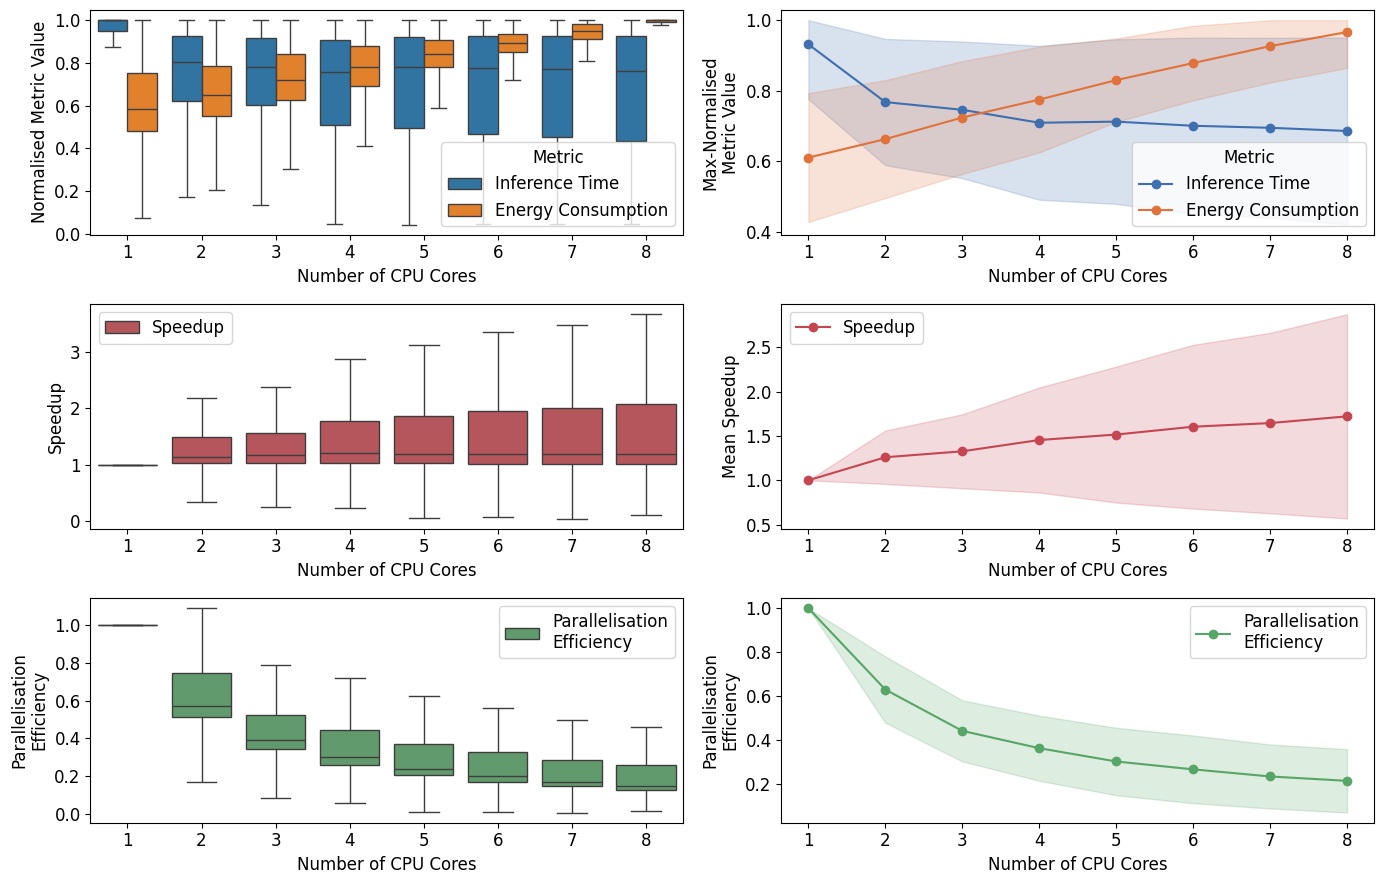

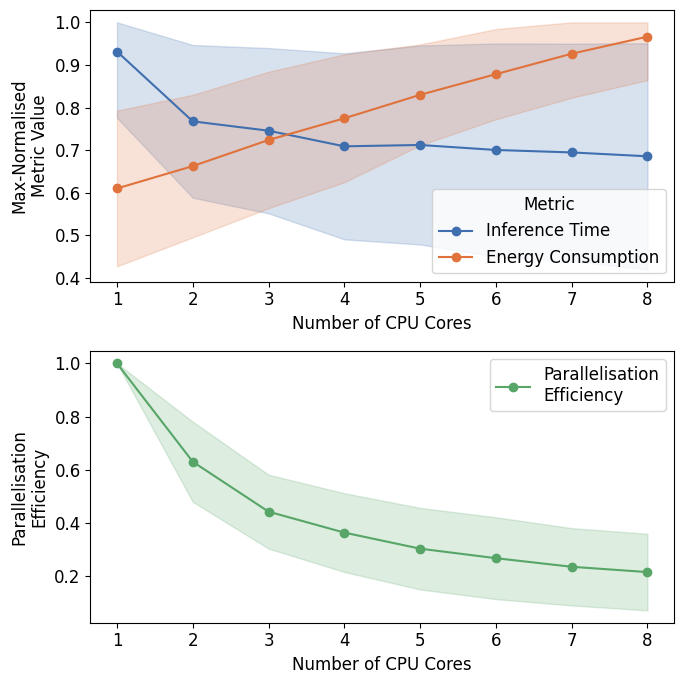

In [11]:
plot_parallel_tradeoff(data_random, frequency=2800000)
plot_parallel_tradeoff(data_random, frequency=2800000, plot_both=False)

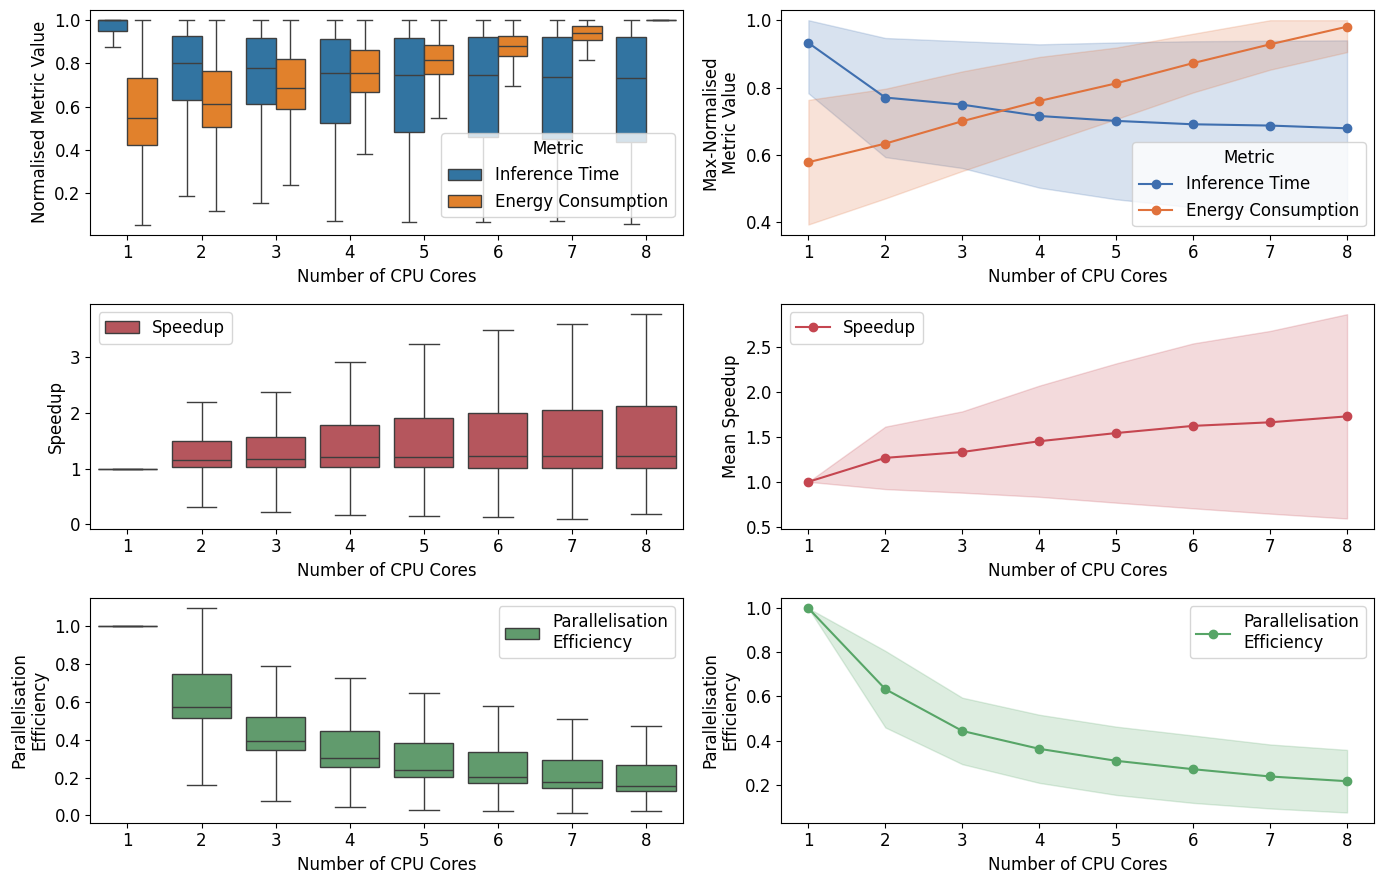

In [25]:
plot_parallel_tradeoff(data_random, frequency="boost")

# Consistency Analysis

In [14]:
print(data_random.columns)

Index(['task_id', 'method', 'seed', 'config_id', 'model', 'time_5fcv', 'bmp_RMSE', 'bmp_inference_time', 'bmp_energy_consumption', 'status',
       ...
       'final_inference_time_freq_boost_cores_7', 'final_energy_consumption_freq_boost_cores_7', 'final_inference_time_freq_boost_cores_8', 'final_energy_consumption_freq_boost_cores_8', 'bmp_Log Loss', 'ensembling_Log Loss', 'final_Log Loss', 'bmp_1 - ROC AUC', 'ensembling_1 - ROC AUC', 'final_1 - ROC AUC'], dtype='object', length=146)


In [15]:
data_by_cores_and_freqs = {}
for n_cores in range(1,9):
    for freq in [1500000, 2100000, 2800000, "boost"]:
        inf_times_ens = data_random[f"ensembling_inference_time_freq_{freq}_cores_{n_cores}"]
        inf_times_final = data_random[f"final_inference_time_freq_{freq}_cores_{n_cores}"]
        energies_ens = data_random[f"ensembling_energy_consumption_freq_{freq}_cores_{n_cores}"]
        energies_final = data_random[f"final_energy_consumption_freq_{freq}_cores_{n_cores}"]
        data_by_cores_and_freqs[(n_cores, freq)] = {
            "inf_times_ens": inf_times_ens,
            "inf_times_final": inf_times_final,
            "energies_ens": energies_ens,
            "energies_final": energies_final
        }

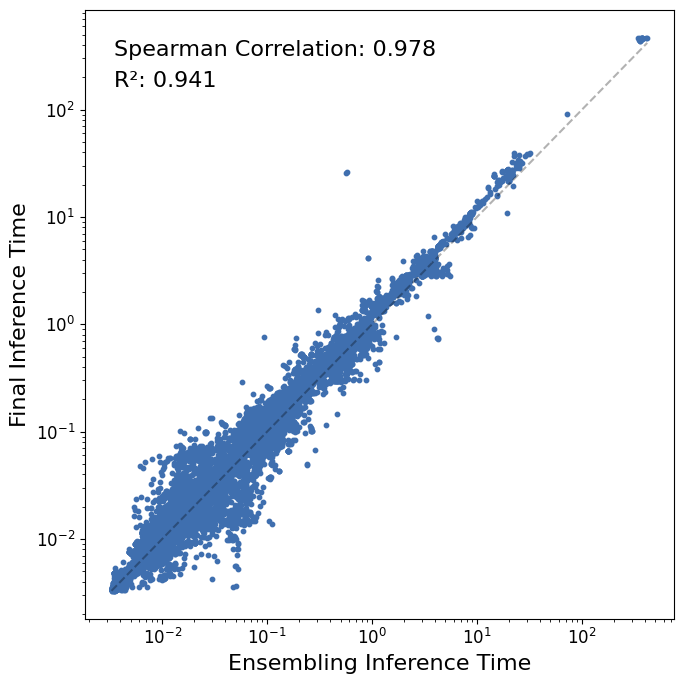

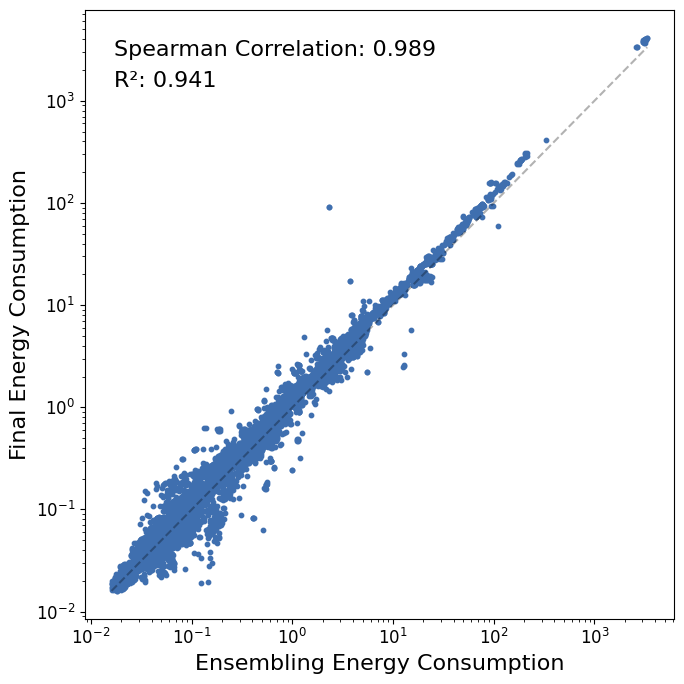

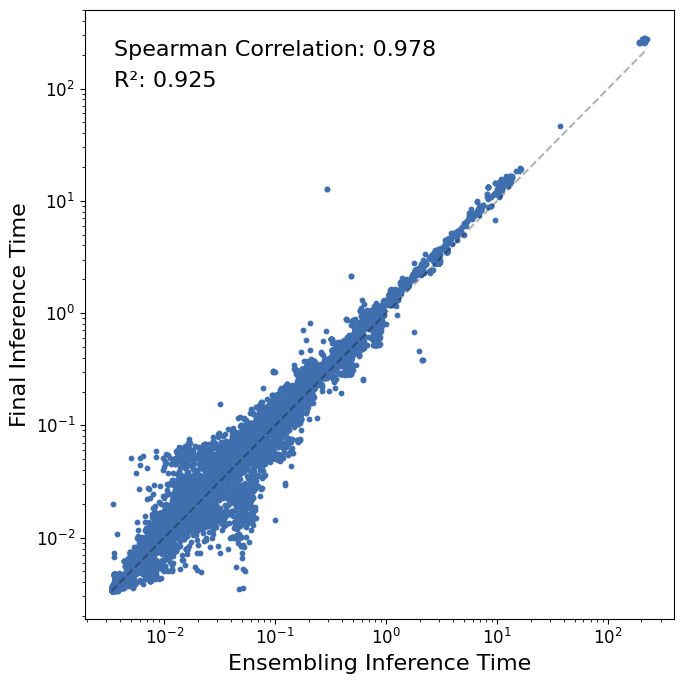

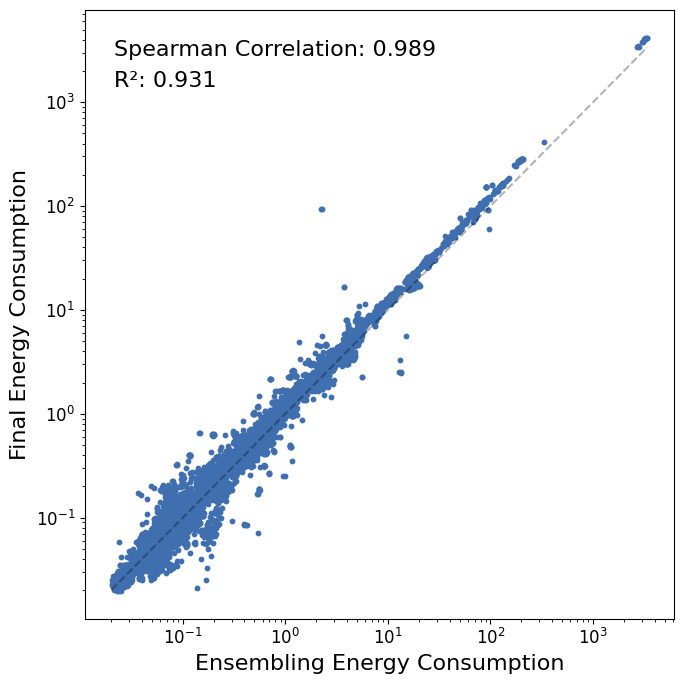

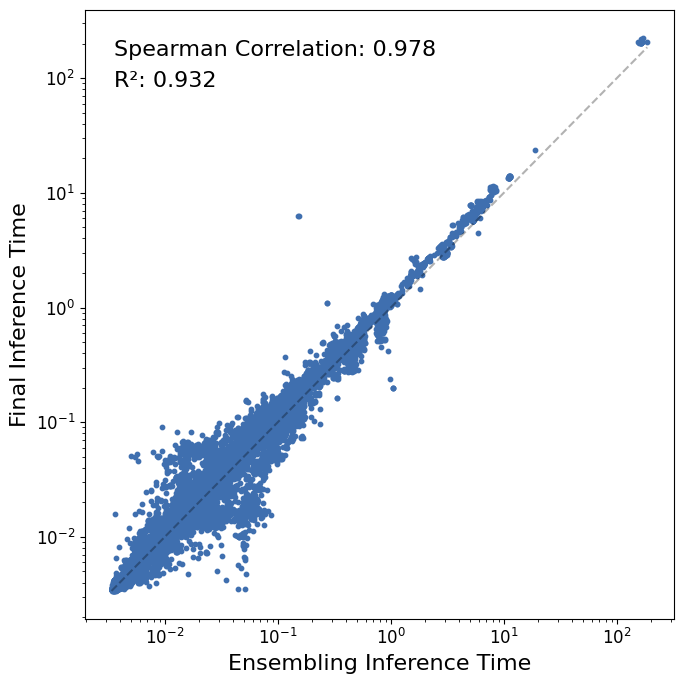

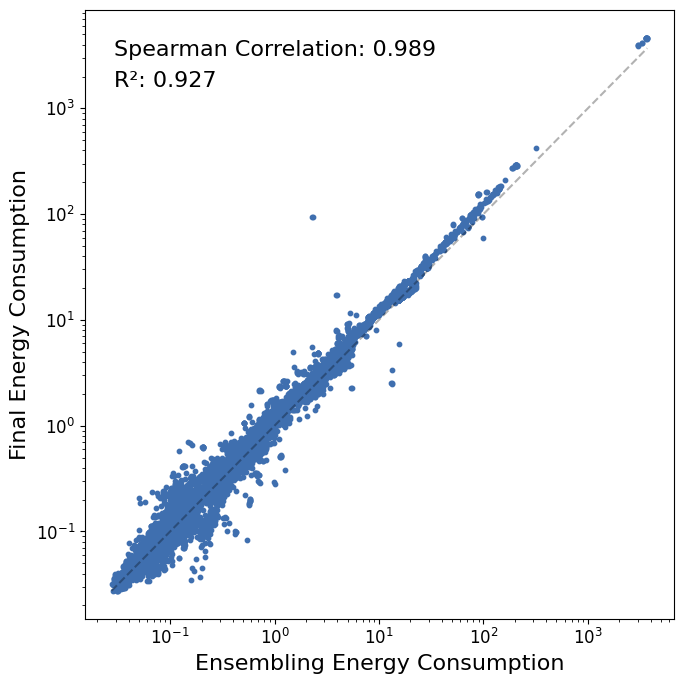

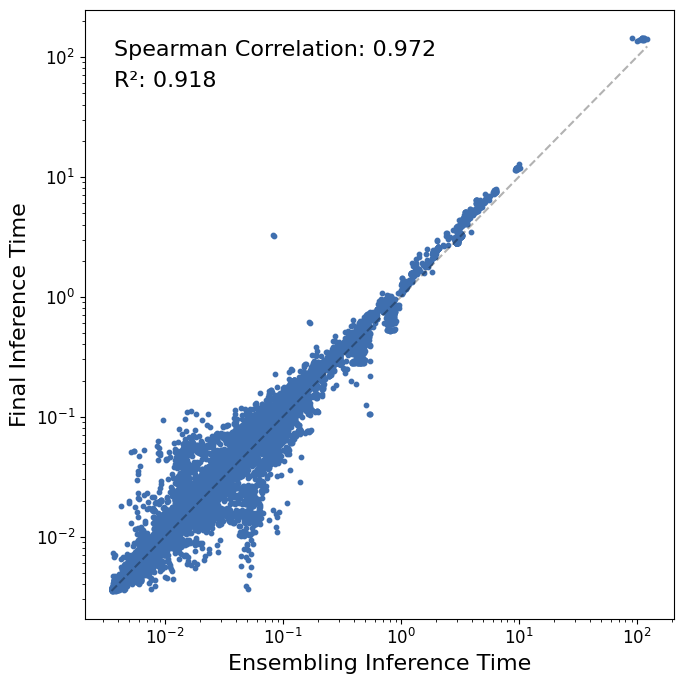

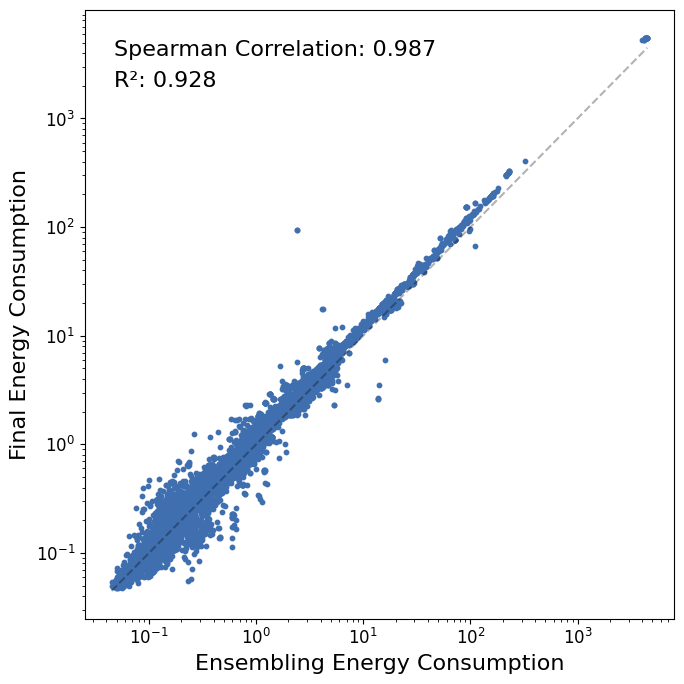

In [17]:
for n_cores in [1,2,4,8]:
    for freq in ["boost"]: #[1500000, 2100000, 2800000, "boost"]:
        for i, metric in enumerate(["inf_times", "energies"]):
            fig, ax = plt.subplots(figsize=(7, 7))
            ens = data_by_cores_and_freqs[(n_cores, freq)][f"{metric}_ens"]
            final = data_by_cores_and_freqs[(n_cores, freq)][f"{metric}_final"]
            ax.scatter(ens, final, color=COLOR_LIST[0], s=10)
            ax.plot([ens.min(), ens.max()], [ens.min(), ens.max()], color='black', alpha=0.3, linestyle='--')
            ax.set_xlabel(f"Ensembling {'Inference Time' if metric == 'inf_times' else 'Energy Consumption'}",fontsize=16)
            ax.set_ylabel(f"Final {'Inference Time' if metric == 'inf_times' else 'Energy Consumption'}",fontsize=16)
            #ax[i].set_title(f"Ensembling vs. Final {metric.replace('_', ' ').title()} at {n_cores} Cores and {freq} Frequency")
            ax.set_xscale("log")
            ax.set_yscale("log")
            #corr = np.corrcoef(ens, final)[0, 1]
            #ax[i].text(0.05, 0.95, f"Pearson Correlation: {corr:.3f}", transform=ax[i].transAxes, verticalalignment='top', fontsize=14)
            r2 = r2_score(ens, final)
            ax.text(0.05, 0.9, f"R²: {r2:.3f}", transform=ax.transAxes, verticalalignment='top', fontsize=16)
            spearman_corr, _ = spearmanr(ens, final)
            ax.text(0.05, 0.95, f"Spearman Correlation: {spearman_corr:.3f}", transform=ax.transAxes, verticalalignment='top', fontsize=16)
            plt.tight_layout()
            plt.savefig(f"./figures/4/consistency_{metric}_{n_cores}.pdf")

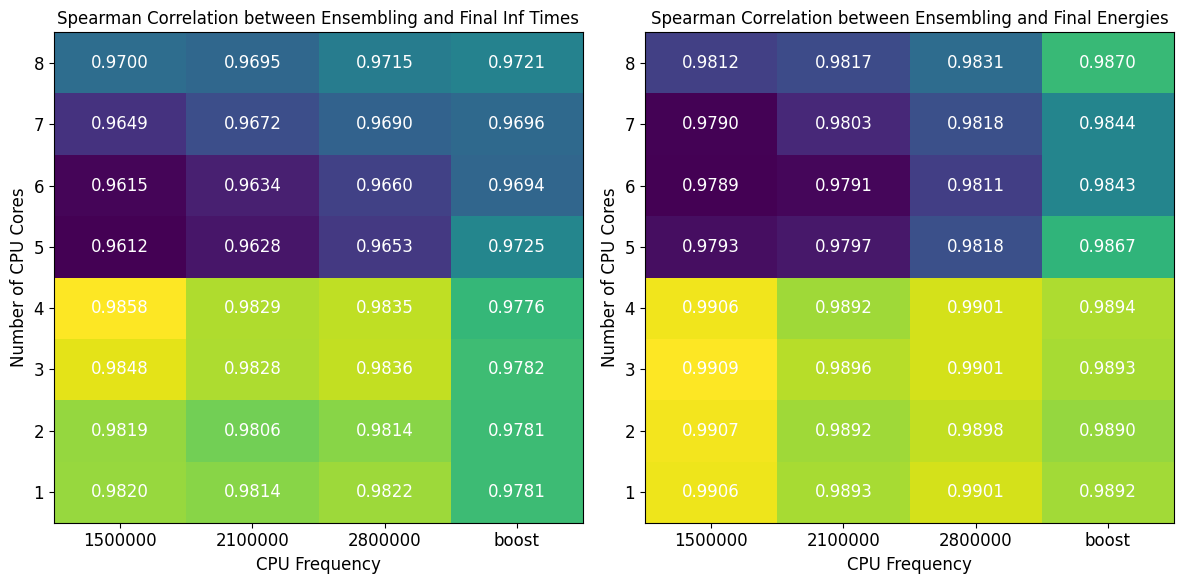

In [22]:
n_cores_list = list(range(1,9))
frequencies = [1500000, 2100000, 2800000, "boost"]
spearman_arr = np.zeros((len(n_cores_list), len(frequencies), 2))

for n_cores in n_cores_list:
    for freq in frequencies:
        for i, metric in enumerate(["inf_times", "energies"]):
            ens = data_by_cores_and_freqs[(n_cores, freq)][f"{metric}_ens"]
            final = data_by_cores_and_freqs[(n_cores, freq)][f"{metric}_final"]
            spearman_corr, _ = spearmanr(ens, final)
            spearman_arr[n_cores - 1, frequencies.index(freq), i] = spearman_corr

fig, ax = plt.subplots(figsize=(12, 6), ncols=2)
for i, metric in enumerate(["inf_times", "energies"]):
    ax[i].imshow(spearman_arr[:, :, i], aspect='auto', cmap='viridis')
    ax[i].set_xticks(np.arange(len(frequencies)), [str(freq) for freq in frequencies])
    ax[i].set_yticks(np.arange(len(n_cores_list)), [str(n) for n in n_cores_list])
    ax[i].set_xlabel("CPU Frequency")
    ax[i].set_ylabel("Number of CPU Cores")
    ax[i].set_title(f"Spearman Correlation between Ensembling and Final {metric.replace('_', ' ').title()}")
    ax[i].invert_yaxis()
    for j in range(len(n_cores_list)):
        for k in range(len(frequencies)):
            ax[i].text(k, j, f"{spearman_arr[j, k, i]:.4f}", ha='center', va='center', color='white' if abs(spearman_arr[j, k, i]) > 0.5 else 'black')
plt.tight_layout()
plt.show()
            

In [23]:
# Creata a latex table summarizing the spearman correlation and the r2 score for inference times and energy consumption across different numbers of CPU cores and frequencies using pandas DataFrame

METRIC_MAP = {
    "inf_times": "Inference Time",
    "energies": "Energy Consumption"
}
FREQ_MAP = {
    1500000: "1.5 GHz",
    2100000: "2.1 GHz",
    2800000: "2.8 GHz",
    "boost": "Boost (3.7 GHz)"
}

summary_data = []
for n_cores in n_cores_list:
    for freq in frequencies:
        for metric in ["inf_times", "energies"]:
            ens = data_by_cores_and_freqs[(n_cores, freq)][f"{metric}_ens"]
            final = data_by_cores_and_freqs[(n_cores, freq)][f"{metric}_final"]
            spearman_corr, _ = spearmanr(ens, final)
            r2 = r2_score(ens, final)
            summary_data.append({
                "Cores": n_cores,
                "Frequency": FREQ_MAP[freq],
                "Metric": METRIC_MAP[metric],
                "Spearman Correlation": spearman_corr,
                "R² Score": r2
            })
summary_df = pd.DataFrame(summary_data)
summary_df.sort_values(by=["Metric", "Cores", "Frequency"], inplace=True)
latex_table = summary_df.to_latex(index=False, float_format="%.4f")
print(latex_table)

\begin{tabular}{rllrr}
\toprule
Cores & Frequency & Metric & Spearman Correlation & R² Score \\
\midrule
1 & 1.5 GHz & Energy Consumption & 0.9906 & 0.9342 \\
1 & 2.1 GHz & Energy Consumption & 0.9893 & 0.9330 \\
1 & 2.8 GHz & Energy Consumption & 0.9901 & 0.9307 \\
1 & Boost (3.7 GHz) & Energy Consumption & 0.9892 & 0.9412 \\
2 & 1.5 GHz & Energy Consumption & 0.9907 & 0.9310 \\
2 & 2.1 GHz & Energy Consumption & 0.9892 & 0.9307 \\
2 & 2.8 GHz & Energy Consumption & 0.9898 & 0.9361 \\
2 & Boost (3.7 GHz) & Energy Consumption & 0.9890 & 0.9308 \\
3 & 1.5 GHz & Energy Consumption & 0.9909 & 0.9348 \\
3 & 2.1 GHz & Energy Consumption & 0.9896 & 0.9347 \\
3 & 2.8 GHz & Energy Consumption & 0.9901 & 0.9302 \\
3 & Boost (3.7 GHz) & Energy Consumption & 0.9893 & 0.9317 \\
4 & 1.5 GHz & Energy Consumption & 0.9906 & 0.9519 \\
4 & 2.1 GHz & Energy Consumption & 0.9892 & 0.9529 \\
4 & 2.8 GHz & Energy Consumption & 0.9901 & 0.9502 \\
4 & Boost (3.7 GHz) & Energy Consumption & 0.9894 & 0.9265 \\